In [3]:
import os
from datetime import datetime, timedelta
import opendrift
from opendrift.models.oceandrift import OceanDrift
from opendrift.readers.reader_netCDF_CF_generic import Reader
import datetime as dt
import copernicusmarine
import numpy as np
from numpy import random
import pandas as pd
import xarray as xr

In [4]:
ds = copernicusmarine.open_dataset(dataset_id='cmems_mod_bal_phy_my_P1D-m', chunk_size_limit=0)
reader_cmems = Reader(ds, name='CMEMS Baltic')

#csv file with the locations of the future turbines
path = '/projappl/project_2018610/data/Wind_farm_position/'
all_region = 'Bothnian_sea_future_turbine_positions_consistent.csv' #1925 turbines
region1 = 'Region1_Bothnian_sea_future_turbine_positions_consistent.csv'#250 turbines
csvfile = path + region1

df = pd.read_csv(csvfile,delimiter=',')
lat = df['1']; lon = df['0']

year = 2018
nb_t = 250 #Number of turbines, depends on the csv file
nb_p = 10 #Number of particles at each seeding place
nb = nb_t * nb_p #Total number of particles
#z = random.uniform(-10, -2, nb_t)
#z = -np.linspace(0, 5, nb_t)
z = -5

tstep = 60 # calculation time step, in minutes
PD = 30   # maximum pelagic propagule duration, in days; not used if None
output_tstep = 60.0 # output time step, in minutes
Kh = 0      # horisontal diffusivity, in m2/s
Kv = 0  # vertical diffusivity, in m2/s
dtmix = 5.0 # vertical mixing timestep, in seconds

o = OceanDrift(loglevel=20)
o.add_reader(reader_cmems, variables=['x_sea_water_velocity', 'y_sea_water_velocity'])

# Configuration settings to modify in wind farm connectivity simulations:

# calculation time step and output time step
o.set_config('general:time_step_minutes', tstep)
o.set_config('general:time_step_output_minutes', output_tstep)

# using auto landmask; if set False, need to provide landmask file
o.set_config('general:use_auto_landmask',True)
# set coastline action, 'previous' or 'stranding'
o.set_config('general:coastline_action', 'stranding')
# if particles get seeded on land, move them to the closest location in sea
o.set_config('seed:ocean_only', True)

# choosing advection scheme, using runge-kutta or runge-kutta 4
o.set_config('drift:advection_scheme', 'runge-kutta4')

# no vertical advection because no vertical velocity components
o.set_config('drift:vertical_advection', False)

# adding horizontal and vertical diffusivities if > 0
if Kh>0:
    o.set_config('drift:horizontal_diffusivity', Kh)
if Kv>0:
    o.set_config('drift:vertical_mixing', True)
    o.set_config('vertical_mixing:timestep', dtmix)  # seconds
    o.set_config('vertical_mixing:diffusivitymodel', 'constant')
    o.set_config('environment:fallback:ocean_vertical_diffusivity',Kv)

# no stokes drift or wind effects; we might want to change these later
o.set_config('drift:stokes_drift', False)
o.set_config('drift:wind_drift_depth', 0.0)
o.set_config('seed:wind_drift_factor', None)

# setting maximum pelagic duration for particles
if PD is not None:
    o.set_config('drift:max_age_seconds',PD*24*3600)

starttime = dt.datetime(year,6,1)
endtime = dt.datetime(year,6,10)
for i in range(0,30,3):
    o.seed_elements(lon=lon, lat=lat, z=z, number=nb, radius=100, time=starttime+dt.timedelta(days=i))

#nb_days = 30
outfol = '/scratch/project_2018610/opendrift_outputs/'
#name_file = 'test_seeding_{}_{}_days_region_1_{}.nc'.format(nb,nb_days,year)
#o.run(duration=timedelta(days=nb_days), outfile=outfol+name_file)
name_file = 'test_seeding_{}_every_third_day_region_1_{}_test.nc'.format(nb,year)
pngname = name_file.replace('.nc','.png')

o.run(end_time=endtime, outfile=outfol+name_file)

INFO - 2026-04-21T11:31:57Z - Selected dataset version: "202303"
INFO - 2026-04-21T11:31:57Z - Selected dataset part: "default"
11:31:59 INFO    opendrift:568: OpenDriftSimulation initialised (version 1.14.9)
11:31:59 INFO    opendrift.models.basemodel.environment:203: Adding a global landmask from GSHHG
11:32:03 INFO    opendrift.models.basemodel.environment:227: Fallback values will be used for the following variables which have no readers: 
11:32:03 INFO    opendrift.models.basemodel.environment:230: 	sea_surface_height: 0.000000
11:32:03 INFO    opendrift.models.basemodel.environment:230: 	x_wind: 0.000000
11:32:03 INFO    opendrift.models.basemodel.environment:230: 	y_wind: 0.000000
11:32:03 INFO    opendrift.models.basemodel.environment:230: 	upward_sea_water_velocity: 0.000000
11:32:03 INFO    opendrift.models.basemodel.environment:230: 	ocean_vertical_diffusivity: 0.000000
11:32:03 INFO    opendrift.models.basemodel.environment:230: 	horizontal_diffusivity: 0.000000
11:32:03 IN

<xarray.Dataset> Size: 143MB
Dimensions:                              (trajectory: 7500, time: 217)
Coordinates:
  * trajectory                           (trajectory) int32 30kB 0 1 ... 7499
  * time                                 (time) datetime64[ns] 2kB 2018-06-01...
Data variables: (12/19)
    status                               (trajectory, time) float64 13MB ...
    moving                               (trajectory, time) float64 13MB ...
    age_seconds                          (trajectory, time) float32 7MB ...
    origin_marker                        (trajectory, time) float64 13MB ...
    lon                                  (trajectory, time) float32 7MB ...
    lat                                  (trajectory, time) float32 7MB ...
    ...                                   ...
    x_wind                               (trajectory, time) float32 7MB ...
    y_wind                               (trajectory, time) float32 7MB ...
    horizontal_diffusivity               (trajectory, time) float32 7MB ...
    sea_surface_wave_significant_height  (trajectory, time) float32 7MB ...
    sea_floor_depth_below_sea_level      (trajectory, time) float32 7MB ...
    land_binary_mask                     (trajectory, time) float32 7MB ...
Attributes: (12/118)
    Conventions:                                                           CF...
    standard_name_vocabulary:                                              CF...
    featureType:                                                           tr...
    title:                                                                 Op...
    summary:                                                               Ou...
    keywords:                                                              tr...
    ...                                                                    ...
    geospatial_lon_units:                                                  de...
    geospatial_lon_resolution:                                             point
    runtime:                                                               0:...
    geospatial_vertical_min:                                               -5.0
    geospatial_vertical_max:                                               -5.0
    geospatial_vertical_positive:                                          up

11:44:13 INFO    opendrift:4048: 	calculating for origin_marker 0...
11:44:13 INFO    opendrift:4048: 	calculating for origin_marker 1...
11:44:13 INFO    opendrift:4048: 	calculating for origin_marker 2...
11:44:13 DEBUG   opendrift:2531: Setting up map: corners=None, fast=True, lscale=None
11:44:13 WARNING opendrift:2565: Plotting fast. This will make your plots less accurate.


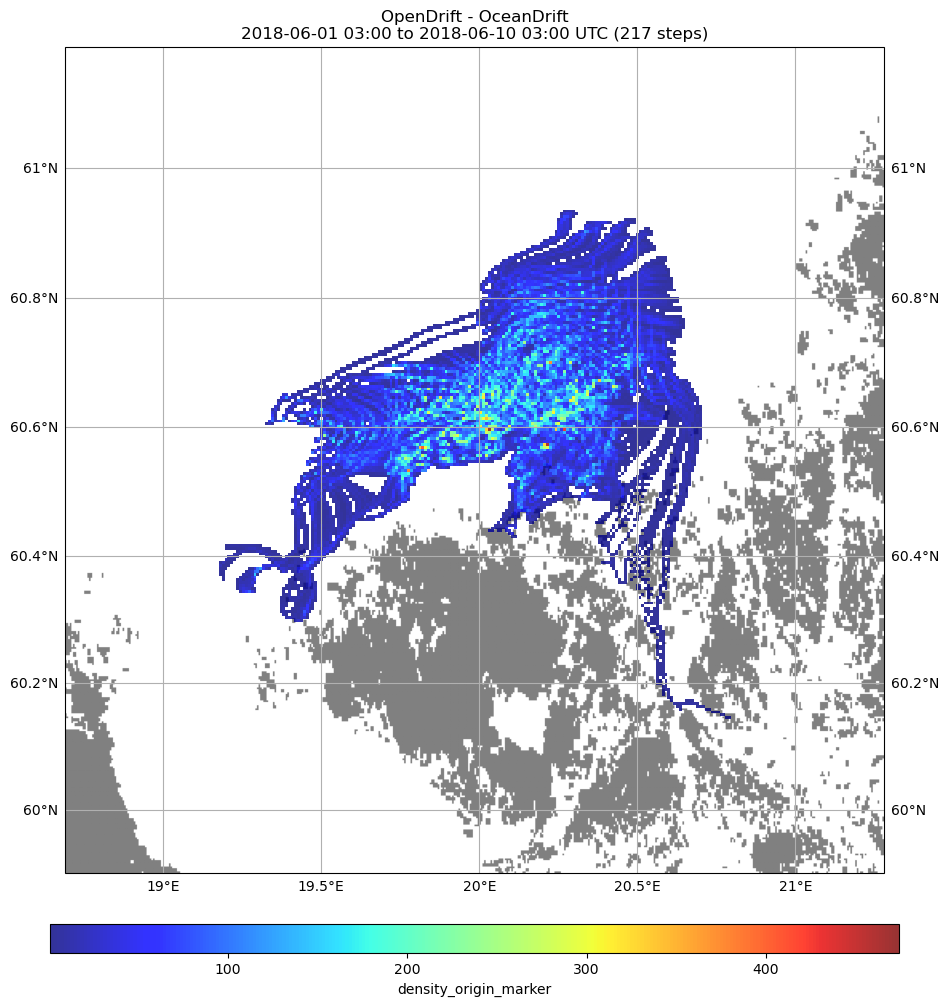

(<GeoAxes: title={'center': 'OpenDrift - OceanDrift\n2018-06-01 03:00 to 2018-06-10 03:00 UTC (217 steps)'}>,
 <Figure size 1090.39x1100 with 2 Axes>)

In [12]:

mas = o.get_histogram(pixelsize_m=500, density=False)
b=mas.isel(origin_marker=0).sum(dim='time')

o.plot(background=b.where(b>0), fast=True, show_elements=False, show_trajectories=False)


# Cleaning up
#os.remove(outfile)
#os.remove(histogram_file)

In [5]:
o = opendrift.open(outfol+name_file)
h = o.get_histogram(pixelsize_m=500)

11:32:35 DEBUG   opendrift.config:168: Adding 17 config items from __init__
11:32:35 DEBUG   opendrift.config:178:   Overwriting config item readers:max_number_of_fails
11:32:35 DEBUG   opendrift.config:168: Adding 5 config items from __init__
11:32:35 INFO    opendrift:568: OpenDriftSimulation initialised (version 1.14.9)
11:32:35 DEBUG   opendrift.config:168: Adding 19 config items from oceandrift
11:32:35 DEBUG   opendrift.config:178:   Overwriting config item seed:z
11:32:35 DEBUG   opendrift.export.io_netcdf:113: Importing from /scratch/project_2018610/opendrift_outputs/test_seeding_2500_every_third_day_region_1_2018_test.nc
11:32:36 DEBUG   opendrift:1802: Removed 370 elements.
11:32:36 DEBUG   opendrift.export.io_netcdf:157: Setting imported config: environment:constant:x_sea_water_velocity -> None
11:32:36 DEBUG   opendrift.export.io_netcdf:157: Setting imported config: environment:fallback:x_sea_water_velocity -> 0
11:32:36 DEBUG   opendrift.export.io_netcdf:157: Setting impor

In [6]:
h

<xarray.DataArray 'density_origin_marker' (time: 217, lon_bin: 178,
                                           lat_bin: 179, origin_marker: 3)> Size: 166MB
array([[[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
...
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]]], shape=(217, 178, 179, 3))
Coordinates:
  * time           (time) datetime64[ns] 2kB 2018-06-01 ... 2018-06-10
  * origin_marker  (origin_marker) int64 24B 0 1 2
  * lon_bin        (lon_bin) float64 1kB 19.17 19.18 19.19 ... 20.77 20.78 20.79
  * lat_bin        (lat_bin) float64 1kB 60.14 60.15 60.15 ... 60.93 60.94 60.94

08:51:52 DEBUG   opendrift:2531: Setting up map: corners=[17.1, 21.6, 60.3, 63.6], fast=True, lscale=None
08:51:52 WARNING opendrift:2565: Plotting fast. This will make your plots less accurate.


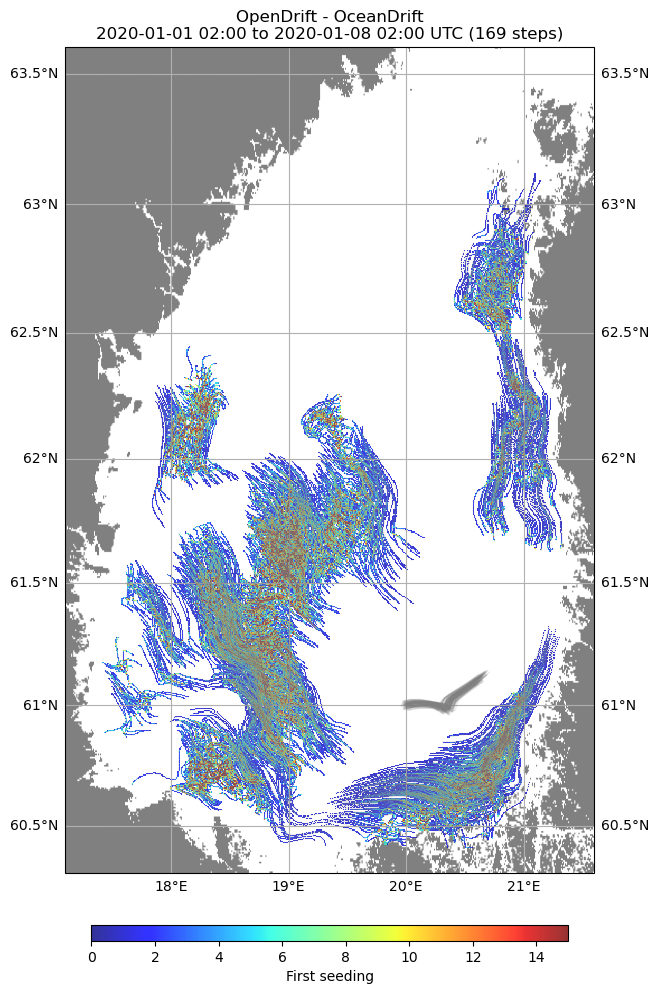

(<GeoAxes: title={'center': 'OpenDrift - OceanDrift\n2020-01-01 02:00 to 2020-01-08 02:00 UTC (169 steps)'}>,
 <Figure size 705.363x1100 with 2 Axes>)

In [21]:
b=h.isel(origin_marker=0).sum(dim='time')
oa.plot(background=b.where(b>0), fast=True, show_elements=False, vmin=0, vmax=15, clabel='First seeding', corners=[17.1,21.6,60.3,63.6])

In [26]:
"""for om in [0, 1]:
    background=h.isel(origin_marker=om)
    oa.animation(background=background.where(background>0), bgalpha=1,
                corners=[17.1,21.6,60.3,63.6], fast=False, show_elements=False, vmin=0, vmax=200)

# Cleaning up
os.remove(name_file)"""

### Didn't work

'for om in [0, 1]:\n    background=h.isel(origin_marker=om)\n    oa.animation(background=background.where(background>0), bgalpha=1,\n                corners=[17.1,21.6,60.3,63.6], fast=False, show_elements=False, vmin=0, vmax=200)\n\n# Cleaning up\nos.remove(name_file)'